# Exercise 3
### Computer Vision, Fall 2025
#### Name: <font color='blue'>*Chiara Zara*</font>
---
**Instructions:**
- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Sunday Sep. 28 at 23.50</font> via Moodle.


## Ex 3.1. CAMERA MATRIX (4 p)
Please find the 3 sets of images provided in the Moodle page of this week's exercise. The three image sets (A,B and C) contain pictures taken of a camera calibration checkerboard pattern with a square size of 3cm.

1. Write a function using built-in OpenCV methods that computes the intrinsic camera calibration matrix and distortion matrix from a given set of calibration images.

2. Apply that function to all three sets of images and observe the results. Based on the results for the intrinsic and distortion matrix, discuss what type of camera or lens was used to capture the different image sets.


In [1]:
import cv2
import numpy as np
import os
import glob
from matplotlib import pyplot as plt

np.set_printoptions(suppress=True)


def calibrate(img_path):
    matrix = None
    distortion = None

    #set the checkerboard size with 8x6 inner corners (the board is 9x7)
    checkerboard_size = (8, 6)  
    #from cm to meter
    square_size = 0.03  # 3 cm

    #3d points for all corners in the board
    objp = np.zeros((checkerboard_size[0]*checkerboard_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard_size[0], 0:checkerboard_size[1]].T.reshape(-1, 2)
    objp *= square_size

    objpoints = []  #save the 3d real points
    imgpoints = []  #save the 2d image points

    images = glob.glob("{}/*.jpeg".format(img_path))

    for filename in images:
        image = cv2.imread(filename)
        grayColor = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        #find the chessboard corners in the image
        ret, corners = cv2.findChessboardCorners(grayColor, checkerboard_size, None)
        if ret:
            objpoints.append(objp)
            #refine the corners
            corners2 = cv2.cornerSubPix(grayColor, corners, (11,11), (-1,-1),
                                        criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
            imgpoints.append(corners2)
        else:
            print(f"No corners found in {filename}")

    if objpoints and imgpoints:
        #calibrate the camera and get matrix and distortion
        ret, matrix, distortion, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, grayColor.shape[::-1], None, None)

    return matrix, distortion


print("Images A:")
matrix, distortion = calibrate("images_A")
print(matrix)
print(distortion)
print()

print("Images B:")
matrix, distortion = calibrate("images_B")
print(matrix)
print(distortion)
print()

print("Images C:")
matrix, distortion = calibrate("images_C")
print(matrix)
print(distortion)


Images A:
[[3414.06020588    0.         1584.97005964]
 [   0.         3412.7613255  1903.84888259]
 [   0.            0.            1.        ]]
[[ 0.171663   -0.6898041  -0.00808318  0.00703094  1.55157987]]

Images B:
[[1707.80263742    0.         1477.72312555]
 [   0.         1704.50583309 1989.87392185]
 [   0.            0.            1.        ]]
[[-0.00571023  0.01908908 -0.00171763 -0.00362863 -0.00341242]]

Images C:
[[7567.6155158     0.         1286.82543306]
 [   0.         7594.36284444 2015.2283118 ]
 [   0.            0.            1.        ]]
[[ -0.17233367   9.05893804  -0.01414264  -0.00978806 -61.28920319]]


#### Answer 

* images_A:   
Intrinsic matrix show very high focal length values (fx=3440.39393404, fy=3438.45431564), this is much bigger than normal camera, so it looks like a telephoto lens or zoom lens. the distortion coef are not very small (k1=0.20, k2=-0.89, k3=2.01) so the image is not perfect corrected.
We can conclude that the set of pictures is probably captured with telephoto or zoom lens with some radial distortion.

*  images_B:  
Intrinsic matrix has focal length around fx=1707.80263742, fy=1704.50583309, this is smaller than before and a more normal value. the distortion coef are almost zero (k1=-0.0057, k2=0.019, k3=-0.0034). this mean the lens is quite corrected and with almost no distortion and so the set B probably is captured with standard lens, like normal camera or smartphone.

*  images_C:  
Intrinsic matrix is extremely high (fx=7567.6155158, fy=7594.36284444). The distortion coef are very strong (k2≈9.05, k3≈-61.28), this show very big radial distortion like barrel shape.
We can conclude that set C probably is captured with fisheye or very wide angle lens.

## Ex 3.2. HOUGH TRANSFORM (4 p)
1. Ask ChatGPT to explain the main points about Hough Transform using the key word "Hough Transform". Analyse the answer by reflecting it to the course material related to Hough Transform: Were all main points in the course material addressed? if no, please shortly conclude the answers of ChatGPT and our course materials regarding the Hough Transform, and list the differences of answers between our course material and ChatGPT.
2. We provided you example images from the Berkeley Segmentation Dataset. Implement the Hough Transform (the most basic version) for line detection by yourself (You may only use the openCV function to check if your solution is correct). Instead of using the default parameters, customize the parameters (e.g., resolution of the parameter space, threshold values for line detection, minimum line length, maximum line gap) to optimize edge detection for the given set of images. Report your observations: which parameters influenced which behaviour in the output? Also report which parameter configuration resembles closest an object segmentation in the test images.


#### Answer 

1.  Chatgpt answer:  
the Hough Transform is a method used in computer vision to detect lines or other shapes in images. chatgpt said that the main idea is to convert points from the image space into a parameter space where each point votes for possible models, for example lines. when many points belong to the same line, their votes intersect in parameter space, and this intersection shows the line in the image. chatgpt also mentioned that the Hough Transform is robust to noise and missing points and can detect lines even if they are disconnected or partially hidden. the result of the Hough Transform is a set of parameters describing the detected lines or shapes, which can then be drawn back on the image.

2. Analysis:  
Chatgpt gives a general explanation of the Hough Transform, but in class we also learned the practical steps, parameter space details, and connections to other computer vision tasks, which makes the understanding more complete. For example, we have learned that:

* to implement the Hough Transform, the parameter space must be quantized and an accumulator array is used
* for each edge point in the image, ρ = x cos θ + y sin θ is computed for different values of θ, and the accumulator is incremented
* local maxima in the accumulator indicate the detected lines in the image
* using polar coordinates is better to avoid very large parameter ranges
* a line in image space corresponds to a point in Hough space, while a single point in image space becomes a wave in Hough space
* Hough Transform can be combined with other estimation methods, such as homography estimation and camera calibration, which chatgpt did not mention
* the method works even if lines are occluded or discontinuous
* it is also important to handle both positive and negative values of ρ

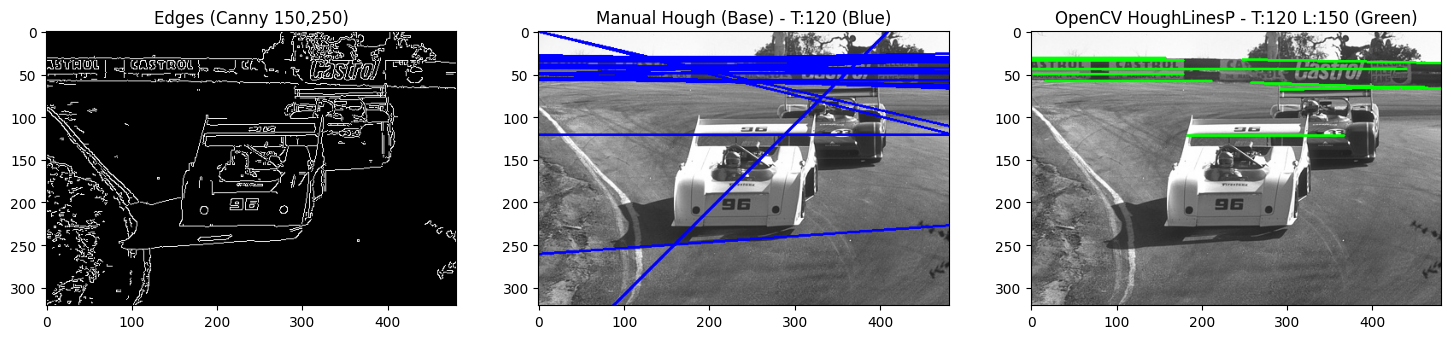

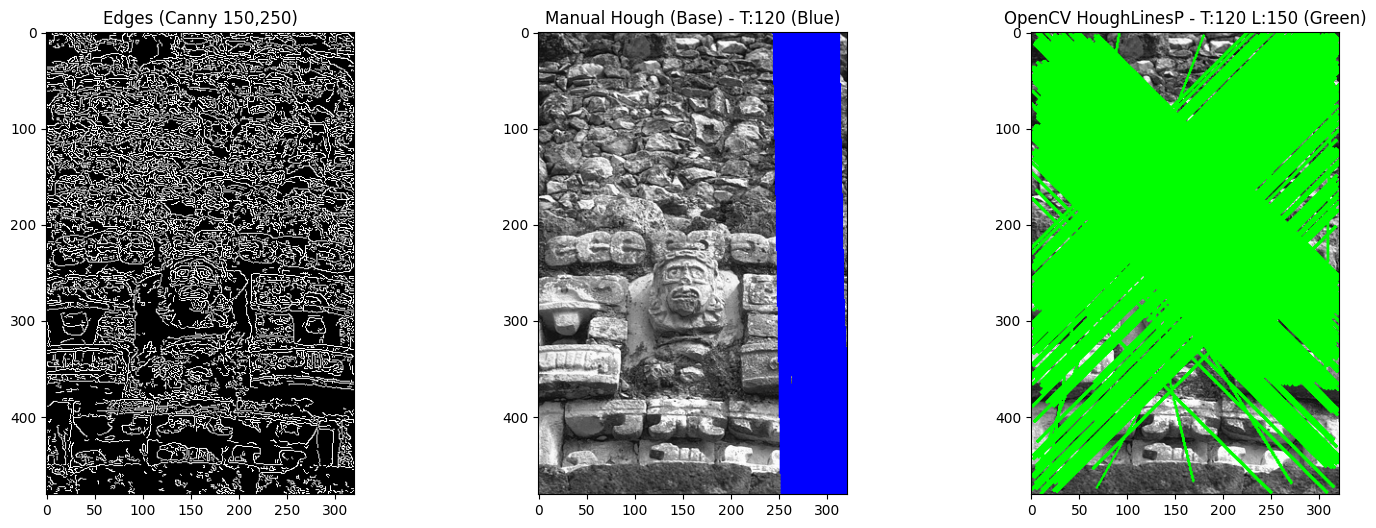

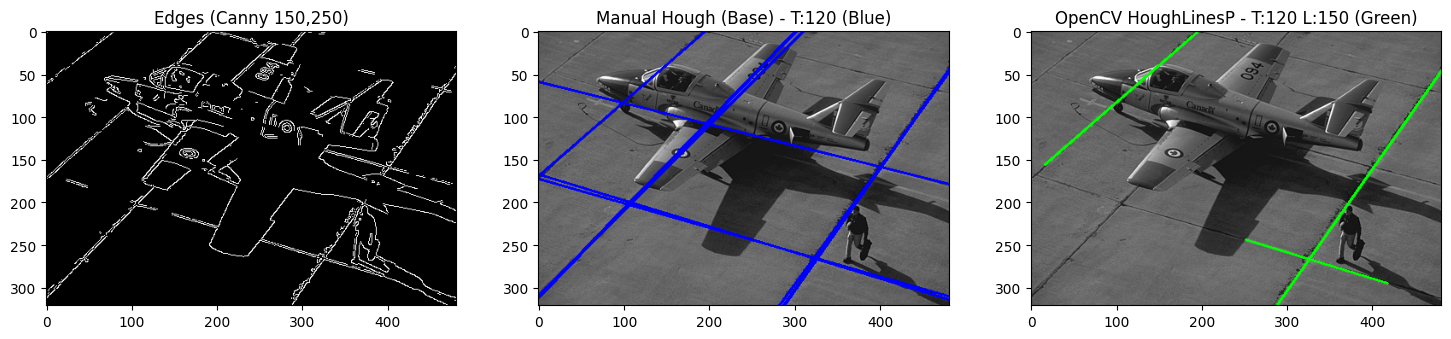

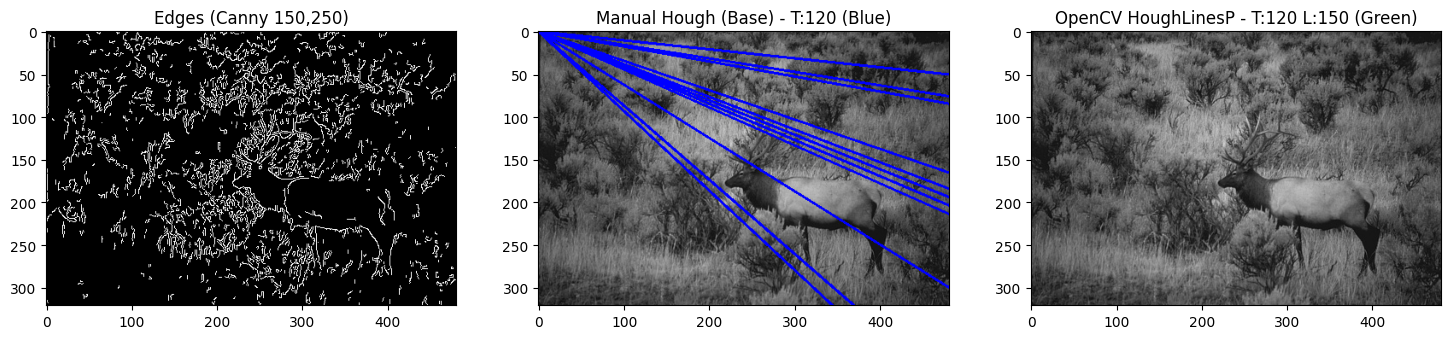

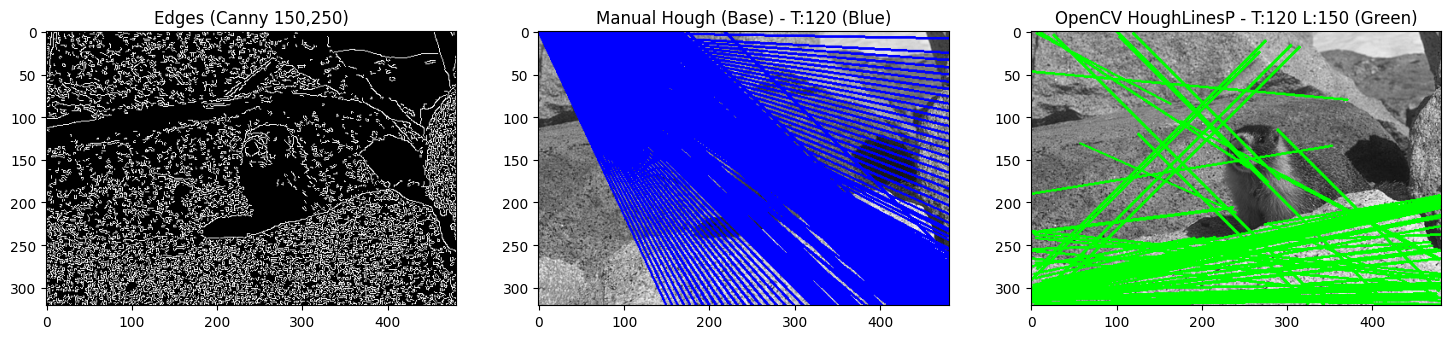

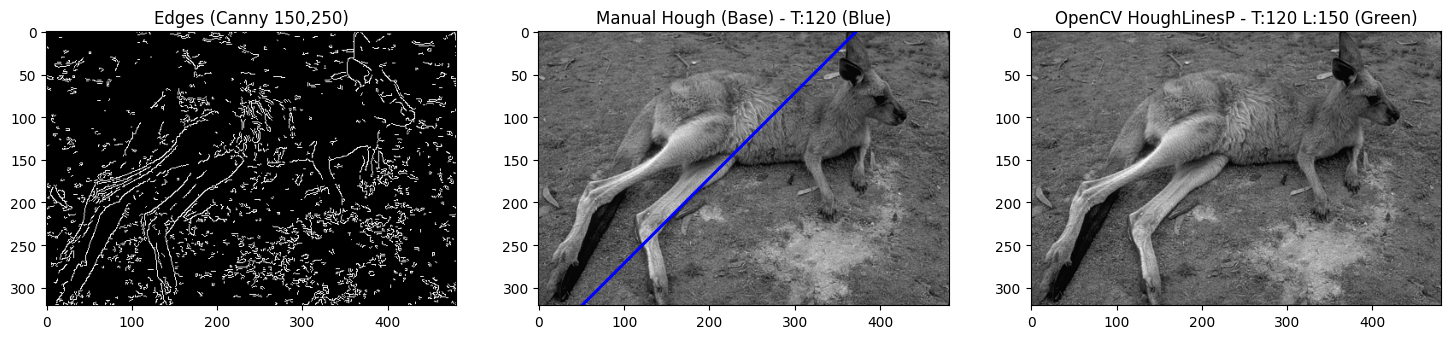

In [2]:
#2)
import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2

#optimized parameters for object segmentation
canny_t1 = 150  # low threshold for canny
canny_t2 = 250  # high threshold for canny
rho_res = 1
theta_res = np.pi / 180
threshold_votes = 120 # vote threshold for OpenCV
min_line_length = 150 # min segment length
max_line_gap = 25 #max gap to join segments

# manual hough transform resolution
rho_res_manual = 1
theta_res_manual = np.pi / 180
threshold_manual = threshold_votes  #align with optimized

def apply_hough_transform(image):
    # detect edges with canny
    edges = cv2.Canny(image, canny_t1, canny_t2)
    height, width = edges.shape

    diag_len = int(np.ceil(np.sqrt(height**2 + width**2))) # max rho
    rhos = np.arange(-diag_len, diag_len + 1, rho_res_manual)
    thetas = np.arange(0, np.pi, theta_res_manual)

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64) #hough space

    y_idxs, x_idxs = np.nonzero(edges) # get edge points
    for x, y in zip(x_idxs, y_idxs):
        for t_idx, theta in enumerate(thetas):
            rho = int(x * np.cos(theta) + y * np.sin(theta)) #compute rho
            rho_idx = np.searchsorted(rhos, rho) # find index
            if 0 <= rho_idx < len(rhos):
                accumulator[rho_idx, t_idx] += 1 #vote in accumulator

    lines = []
    for r_idx in range(accumulator.shape[0]):
        for t_idx in range(accumulator.shape[1]):
            if accumulator[r_idx, t_idx] >= threshold_manual:
                rho = rhos[r_idx]
                theta = thetas[t_idx]
                lines.append((rho, theta)) # store line
    return edges, lines

def draw_lines_manual(image, lines):
    img_out = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR) #convert to color
    for rho, theta in lines[:200]: # draw only first 200
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 2000 * (-b)) # extend line
        y1 = int(y0 + 2000 * (a))
        x2 = int(x0 - 2000 * (-b))
        y2 = int(y0 - 2000 * (a))
        cv2.line(img_out, (x1, y1), (x2, y2), (0, 0, 255), 2) #blue line
    return img_out

images = glob.glob("segmentation_images/*.jpg")

for filename in images:
    image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"cannot read {filename}")
        continue  # skip if cannot read

    # apply manual hough transform
    edges, lines_manual = apply_hough_transform(image)
    manual_img = draw_lines_manual(image, lines_manual)

    # apply opencv houghlinesp
    line_img_cv = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR) #convert for green lines
    lines_cv = cv2.HoughLinesP(edges,
                               rho=rho_res,
                               theta=theta_res,
                               threshold=threshold_votes,
                               minLineLength=min_line_length,
                               maxLineGap=max_line_gap)
    if lines_cv is not None:
        for line in lines_cv:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2) #green segments

    # plot results
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.title(f"Edges (Canny {canny_t1},{canny_t2})")
    plt.imshow(edges, cmap='gray')

    plt.subplot(1, 3, 2)
    plt.title(f"Manual Hough (Base) - T:{threshold_manual} (Blue)") #corrected
    plt.imshow(manual_img)

    plt.subplot(1, 3, 3)
    plt.title(f"OpenCV HoughLinesP - T:{threshold_votes} L:{min_line_length} (Green)")
    plt.imshow(line_img_cv)

    plt.show()


The exercise focused on implementing the basic Hough Transform manually and optimizing parameters for object segmentation. The main goal was to keep strong object edges while reducing noise from textures.
For the manual Hough Transform, the Canny thresholds (150,250) were important because they removed most of the texture noise but still kept the strong edges of objects. The threshold value of 120 worked well to detect meaningful contours without picking up too much random noise. The standard resolutions, rho_res=1 and theta_res=π/180, provided a good balance between precision and computation time.
Comparing manual Hough and OpenCV’s HoughLinesP, the manual version (blue lines) draws infinite lines across the whole image, which makes it less useful for discrete object segmentation. HoughLinesP (green lines), on the other hand, generates finite line segments with controlled lengths and gaps, which works much better for outlining specific objects.
The best configuration for segmenting geometric objects was Canny(150,250) for clean edge detection, threshold=120 to balance sensitivity and selectivity, min_line_length=150 to filter out noise but keep main contours, and max_line_gap=25 to connect small broken segments. With these settings, the segmentation worked well on geometric shapes like cars and airplanes.
However, the method struggled with organic or curved shapes that don’t produce straight line segments. Manual Hough’s infinite lines were particularly less useful in these cases, while HoughLinesP still provided meaningful segments where possible.
In conclusion, the basic Hough Transform can outline main geometric structures, but HoughLinesP with optimized parameters gives more useful and realistic results for object segmentation and boundary detection.